In [ ]:
# Name: Gopinadh Muttavarapu
# COURSE: COMP 690
# Imports math library

# Run this if you're in a Colab to install MNIST 1D repository
!pip install git+https://github.com/greydanus/mnist1d

  Cloning https://github.com/greydanus/mnist1d to /tmp/pip-req-build-c4v2w_oo
  Running command git clone --filter=blob:none --quiet https://github.com/greydanus/mnist1d /tmp/pip-req-build-c4v2w_oo
  Resolved https://github.com/greydanus/mnist1d to commit 7878d96082abd200c546a07a4101fa90b30fdf7e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mnist1d: filename=mnist1d-0.0.2.post16-py3-none-any.whl size=14664 sha256=467c58f9377f79a2250d5aa7290eb23651b844aaee7cfac9d6cc4780d1014953
  Stored in directory: /tmp/pip-ephem-wheel-cache-_o68_y85/wheels/18/40/b6/29381fee9b4c80fdbc304d52bb065a7286bbcca5ca2b8737c0
Successfully built mnist1d


**1. Import Libraries**

In [ ]:
# ------------------------------
# 1. Import Libraries
# ------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.utils import class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


**Connecting to Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/DeepLearning_Project/creditcard.csv"

Mounted at /content/drive


In [ ]:
df = pd.read_csv(path, compression='zip')
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

**2. Load Dataset**

In [ ]:
# ------------------------------
# 2. Load Dataset
# ------------------------------

df = pd.read_csv(path, compression='zip')

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

**3. Data Exploration**


Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


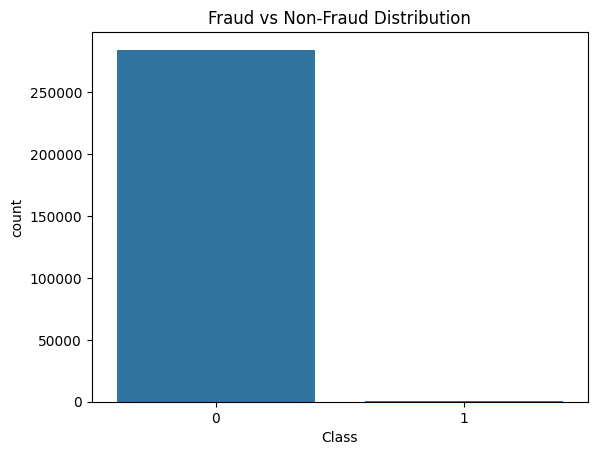

In [ ]:
# ------------------------------
# 3. Data Exploration
# ------------------------------
print("\nClass Distribution:")
print(df['Class'].value_counts())

# Plot imbalance
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

**4. Data Preprocessing**

In [ ]:
# ------------------------------
# 4. Data Preprocessing
# ------------------------------
# Scale Amount and Time
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

# Features and Target
X = df.drop("Class", axis=1)
y = df["Class"]

**5. Train-Test Split**

In [ ]:
# ------------------------------
# 5. Train-Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**6. Handle Class Imbalance**

In [ ]:
# ------------------------------
# 6. Handle Class Imbalance
# ------------------------------
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: weights[0], 1: weights[1]}
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}


**7. Build Deep Learning Model**

In [ ]:
# ------------------------------
# 7. Build Deep Learning Model
# ------------------------------
model = Sequential()

# Input Layer
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))

# Hidden Layers
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**8. Compile Model**

In [ ]:
# ------------------------------
# 8. Compile Model
# ------------------------------
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**9. Train Model**

In [ ]:
# ------------------------------
# 9. Train Model
# ------------------------------
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=2048,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9010 - loss: 0.8155 - val_accuracy: 0.9433 - val_loss: 0.3268
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9465 - loss: 0.2692 - val_accuracy: 0.9663 - val_loss: 0.1665
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9610 - loss: 0.1996 - val_accuracy: 0.9746 - val_loss: 0.1170
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9621 - loss: 0.1644 - val_accuracy: 0.9700 - val_loss: 0.1156
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9631 - loss: 0.1648 - val_accuracy: 0.9752 - val_loss: 0.0967
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9650 - loss: 0.1432 - val_accuracy: 0.9743 - val_loss: 0.0943
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9690 - loss: 0.1375 - val_accuracy: 0.9749 - val_loss: 0.0894
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9624 - loss: 0.1407 - val_accuracy: 

**10. Predictions**

In [ ]:
# ------------------------------
# 10. Predictions
# ------------------------------
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


**11. Evaluation**

In [ ]:
# ------------------------------
# 11. Evaluation
# ------------------------------
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_prob))


Confusion Matrix:
[[55860  1004]
 [    9    89]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.08      0.91      0.15        98

    accuracy                           0.98     56962
   macro avg       0.54      0.95      0.57     56962
weighted avg       1.00      0.98      0.99     56962


ROC-AUC Score:
0.979328049452758


**12. Visualization**

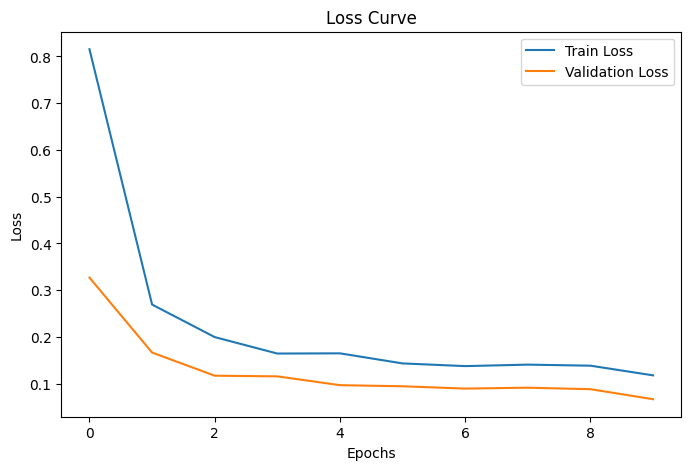

In [ ]:
# ------------------------------
# 12. Visualization
# ------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

**13. Save Model**

In [ ]:
# ------------------------------
# 13. Save Model
# ------------------------------
model.save("fraud_detection_model.h5")

print("\nModel training completed successfully!")


Model training completed successfully!
